# Flood Prediction – Rio Grande do Sul

Objetivo:
Prever a ocorrência de enchentes (nível do rio acima da cota de inundação)
com horizonte de previsão de 3 dias.

Fontes:
- INMET
- ANA
- Atlas Digital de Desastres
- ENSO / Niño Index

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
from keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

c:\Users\pedro\Desktop\6mestre\ds\visualization_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configurações Globais

In [56]:
LOOKBACK = 14
FORECAST = 3

RANDOM_STATE = 42

FEATURES = [
    "precipitacao",
    "temperatura",
    "pressao",
    "umidade",
    "vento",
    #"nivel_rio",
    "nino_index",
    "danos_humanos_diretos",
]

TARGET = "enchente_3d"

# Quando os dados estiverem carregados, use:
# df = create_flood_target(df)
# df = create_forecast_target(df, forecast=FORECAST)

## Dataset Schema

Este projeto trabalha com observações por estação hidrológica.

Chave primária:

- data_hora
- estacao_id

Variáveis meteorológicas:
- precipitacao
- temperatura
- pressao
- umidade
- vento

Variáveis hidrológicas:
- nivel_rio
- cota_inundacao

Variáveis climáticas:
- nino_index

Target:
- enchente
- enchente_3d (horizonte de 3 dias)

### Controle de experimentos

In [57]:
EXPERIMENT_NAME = "baseline_v1_provisorio_sem_ana"

TRAIN_END = "2022-12-31"
VALID_END = "2023-12-31"

USE_NINO = True
USE_RIVER_LEVEL = False
USE_PRECIP_ACCUM = True

## 2. Carregar e tratar os dados

Os dados foram obtidos a partir de arquivos CSV disponibilizados pelo Instituto Nacional de Meteorologia (INMET), sendo referentes ao ano de 2024 para possibilitar uma análise detalhada de todos os fatores que influenciaram os eventos meteorológicos extremos daquele ano. Fora isso, foram renomeados os atributos, para facilitar sua visualização, além da data e hora que foram convertidas em datetime.

In [58]:
def load_csv_data(path, date_col="data", sep=";", decimal=",", dayfirst=True):
    df = pd.read_csv(path, sep=sep, decimal=decimal)
    if date_col in df.columns:
        df = df.rename(columns={date_col: "data_hora"})
    df["data_hora"] = pd.to_datetime(df["data_hora"], dayfirst=dayfirst, errors="coerce")
    return df


def load_inmet_folder(folder_path):
    """
    Lê a pasta do INMET contendo subpastas ou arquivos CSV de múltiplos anos
    e consolida os dados de todas as estações do RS.
    """
    all_stations_data = []
    
    # Procura por todos os arquivos .CSV de forma recursiva nas pastas indicadas
    csv_files = glob.glob(os.path.join(folder_path, "**", "*.CSV"), recursive=True)
    
    for file in csv_files:
        # Lendo os metadados do cabeçalho do INMET
        try:
            with open(file, 'r', encoding='latin-1') as f:
                header = [f.readline().strip() for _ in range(8)]
            
            estacao = header[2].split(';')[1]
            codigo_wmo = header[3].split(';')[1]
            
            # Lendo os dados efetivos (pulando as 8 linhas de cabeçalho)
            df_st = pd.read_csv(file, sep=';', decimal=',', skiprows=8, encoding='latin-1')
            
            # Limpando colunas vazias geradas por ponto e vírgula extra no fim da linha
            df_st = df_st.dropna(how='all', axis=1)
            
            # Renomeando as colunas principais para o padrão esperado pelo notebook
            rename_dict = {
                df_st.columns[0]: "data",
                df_st.columns[1]: "hora",
                "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)": "precipitacao",
                "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)": "pressao",
                "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)": "temperatura",
                "UMIDADE RELATIVA DO AR, HORARIA (%)": "umidade",
                "VENTO, VELOCIDADE HORARIA (m/s)": "vento"
            }
            # Garante compatibilidade mesmo com caracteres especiais corrompidos
            for col in df_st.columns:
                if "PRECIPIT" in col.upper(): rename_dict[col] = "precipitacao"
                elif "PRESSAO ATMOSFERICA AO" in col.upper(): rename_dict[col] = "pressao"
                elif "BULBO SECO" in col.upper(): rename_dict[col] = "temperatura"
                elif "UMIDADE RELATIVA" in col.upper(): rename_dict[col] = "umidade"
                elif "VELOCIDADE HORARIA" in col.upper(): rename_dict[col] = "vento"

            df_st = df_st.rename(columns=rename_dict)
            
            # Tratando campos de Data e Hora
            df_st['data'] = df_st['data'].astype(str).str.replace('/', '-')
            df_st['hora'] = df_st['hora'].astype(str).str.replace(' UTC', '')
            df_st['data_hora'] = pd.to_datetime(df_st['data'] + ' ' + df_st['hora'], errors='coerce')
            
            df_st['estacao_id'] = codigo_wmo
            df_st['municipio'] = estacao
            
            # Mantendo apenas o essencial e dropando linhas sem data_hora válida
            df_st = df_st.dropna(subset=['data_hora'])
            all_stations_data.append(df_st[['data_hora', 'estacao_id', 'municipio', 'precipitacao', 'temperatura', 'pressao', 'umidade', 'vento']])
        except Exception as e:
            print(f"Erro ao processar arquivo {file}: {e}")
            continue
            
    if len(all_stations_data) == 0:
        raise ValueError("Nenhum dado do INMET foi carregado com sucesso.")
        
    df_inmet = pd.concat(all_stations_data, ignore_index=True)
    return df_inmet


def load_ana_data(path):
    return load_csv_data(path, date_col="data")


def load_disaster_data(path):
    # Formato com delimitador em vírgula padrão
    df = pd.read_csv(path, sep=',')
    df['data_evento'] = pd.to_datetime(df['Data_Evento'], dayfirst=True, errors='coerce')
    
    # Simplificando colunas cruciais
    df = df.rename(columns={
        'Nome_Municipio': 'municipio',
        'DH_total_danos_humanos_diretos': 'danos_humanos_diretos',
        'DH_OUTROS AFETADOS': 'outros_afetados'
    })
    
    # Tratando nomes de municípios para evitar problemas de merge por acentuação/caixa
    df['municipio_match'] = df['municipio'].str.upper().str.strip()
    # Criamos uma coluna simplificada apenas com a data (sem hora) para acoplamento diário
    df['data_pura'] = df['data_evento'].dt.date
    
    return df[['data_pura', 'municipio_match', 'danos_humanos_diretos', 'outros_afetados']]


def load_nino_data(path):
    # Formato: "DateTime";"índice" com decimal em vírgula
    df = pd.read_csv(path, sep=';', decimal=',')
    df = df.rename(columns={df.columns[0]: "data_hora", df.columns[1]: "nino_index"})
    df['data_hora'] = pd.to_datetime(df['data_hora'], errors='coerce')
    # Como o índice El Niño é mensal, extrairemos o Ano-Mês para fazer o merge correto depois
    df['ano_mes'] = df['data_hora'].dt.to_period('M')
    return df[['ano_mes', 'nino_index']]


# Example placeholders for your local dataset paths.
# Atualize estes caminhos para os arquivos reais antes de executar.
INMET_PATH = "C:/Users/pedro/Desktop/6mestre/ds/visualization_project/INMET_data/"
ANA_PATH = "path/to/ana_data.csv"
DISASTER_PATH = "Desastres_Hidrologicos_RS.csv"
NINO_PATH = "oceanic-nio-index-oni-me.csv"

# Exemplo de uso:
weather_df = load_inmet_folder(INMET_PATH)
# river_df = load_ana_data(ANA_PATH)
disaster_df = load_disaster_data(DISASTER_PATH)
nino_df = load_nino_data(NINO_PATH)

## 3. Integração das fontes

In [59]:
def merge_datasets(weather_df, disaster_df, nino_df):
    df = weather_df.copy()
    
    # Preparando chaves para acoplamentos temporais e geográficos adicionais
    df['municipio_match'] = df['municipio'].str.upper().str.strip()
    df['data_pura'] = df['data_hora'].dt.date
    df['ano_mes'] = df['data_hora'].dt.to_period('M')
    
    # 1. Merge com o Nino Index (chave: Ano-Mês)
    df = df.merge(nino_df, on='ano_mes', how='left')
    
    # 2. Merge com dados de Desastres (chave: Data e Município)
    df = df.merge(disaster_df, on=['data_pura', 'municipio_match'], how='left')
    
    # Preenche com 0 onde não houve registro de desastre ou danos naquele dia/local
    df['danos_humanos_diretos'] = df['danos_humanos_diretos'].fillna(0)
    df['outros_afetados'] = df['outros_afetados'].fillna(0)
    
    # Criamos um indicador binário de que um evento adverso de enchente ocorreu
    # (Se danos_humanos_diretos > 0 ou se houve algum afetado registrado, assumimos como enchente)
    df['enchente'] = ((df['danos_humanos_diretos'] > 0) | (df['outros_afetados'] > 0)).astype(int)
    
    # Ordenação temporal necessária para modelos sequenciais/janelados
    df = df.sort_values(["estacao_id", "data_hora"]).reset_index(drop=True)
    
    # Remoção de colunas auxiliares de merge
    df = df.drop(columns=['municipio_match', 'data_pura', 'ano_mes'])
    return df


def validate_dataset(df, name="dataset"):
    print(f"==== Validação: {name} ====")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Types:\n", df.dtypes)
    print("Missing values:\n", df.isna().sum())
    print("Unique stations:", df["estacao_id"].nunique() if "estacao_id" in df.columns else "N/A")
    print("Date range:", df["data_hora"].min(), df["data_hora"].max())
    print("===========================\n")
    return df


# Exemplo de uso:
merged_df = merge_datasets(weather_df, disaster_df, nino_df)
validate_dataset(merged_df, name="Merged data")

==== Validação: Merged data ====
Shape: (536064, 12)
Columns: ['data_hora', 'estacao_id', 'municipio', 'precipitacao', 'temperatura', 'pressao', 'umidade', 'vento', 'nino_index', 'danos_humanos_diretos', 'outros_afetados', 'enchente']
Types:
 data_hora                datetime64[us]
estacao_id                          str
municipio                           str
precipitacao                    float64
temperatura                     float64
pressao                         float64
umidade                         float64
vento                           float64
nino_index                      float64
danos_humanos_diretos           float64
outros_afetados                 float64
enchente                          int64
dtype: object
Missing values:
 data_hora                    0
estacao_id                   0
municipio                    0
precipitacao             53315
temperatura              46814
pressao                  45964
umidade                  52856
vento                    7211

,data_hora,estacao_id,municipio,precipitacao,temperatura,pressao,umidade,vento,nino_index,danos_humanos_diretos,outros_afetados,enchente
0,2020-01-01 00:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.4,88.0,1.1,0.5,0.0,0.0,0
1,2020-01-01 01:00:00,A801,PORTO ALEGRE,0.2,24.9,1000.5,88.0,0.7,0.5,0.0,0.0,0
2,2020-01-01 02:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.2,85.0,0.7,0.5,0.0,0.0,0
3,2020-01-01 03:00:00,A801,PORTO ALEGRE,0.0,25.3,999.9,82.0,2.3,0.5,0.0,0.0,0
4,2020-01-01 04:00:00,A801,PORTO ALEGRE,0.0,25.1,999.2,81.0,1.1,0.5,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
536059,2026-05-31 19:00:00,B841,TORRES-AEROPORTO,0.0,19.4,1017.9,85.0,1.4,NaN,0.0,0.0,0
536060,2026-05-31 20:00:00,B841,TORRES-AEROPORTO,0.0,19.1,1018.3,86.0,2.3,NaN,0.0,0.0,0
536061,2026-05-31 21:00:00,B841,TORRES-AEROPORTO,0.0,18.3,1018.8,91.0,2.5,NaN,0.0,0.0,0
536062,2026-05-31 22:00:00,B841,TORRES-AEROPORTO,0.0,17.8,1019.3,93.0,2.4,NaN,0.0,0.0,0


## 4. Identify target and predictors

In [60]:
def create_flood_target(df):
    #if "nivel_rio" not in df.columns or "cota_inundacao" not in df.columns:
     #   raise KeyError("As colunas 'nivel_rio' e 'cota_inundacao' são necessárias para criar o target.")

    #df = df.copy()
    #df["enchente"] = (df["nivel_rio"] >= df["cota_inundacao"]).astype(int)
    return df


def create_forecast_target(df, forecast=FORECAST):
    df = df.sort_values(["estacao_id", "data_hora"]).copy()

    # Define se haverá enchente (registro de desastre) nas próximas X horas/dias horizontes
    # Se os dados estiverem em formato horário, lembre-se que 3 dias correspondem a 72 linhas (3 * 24)
    # Assumindo que seu dataset esteja consolidado em dias ou horas, o rolling lida com a janela de linhas:
    def future_max(group):
        return (
            group["enchente"]
            .rolling(window=forecast, min_periods=1)
            .max()
            .shift(-forecast + 1)
        )

    df["enchente_3d"] = df.groupby("estacao_id", group_keys=False).apply(future_max).fillna(0).astype(int)
    return df


# Exemplo de uso:
# df = create_flood_target(df)
merged_df = create_forecast_target(merged_df, forecast=FORECAST)
# TARGET = "enchente_3d"  # use para previsão em horizonte de 3 dias

## 5. Feature Engineering

In [61]:
def create_features(df):
    df = df.sort_values(["estacao_id", "data_hora"]).copy()
    group = df.groupby("estacao_id")

    df["precip_3d"] = group["precipitacao"].rolling(3, min_periods=1).sum().reset_index(level=0, drop=True)
    df["precip_7d"] = group["precipitacao"].rolling(7, min_periods=1).sum().reset_index(level=0, drop=True)
    df["precip_14d"] = group["precipitacao"].rolling(14, min_periods=1).sum().reset_index(level=0, drop=True)

    #df["delta_rio_1d"] = group["nivel_rio"].diff(1)
    #df["delta_rio_3d"] = group["nivel_rio"].diff(3)

    # Indicador combinado de tempestade severa
    df["fator_tempestade"] = df["precip_3d"] * (1013.25 - df["pressao"])
    df["umidade_chuva_14d"] = df["umidade"] * df["precip_14d"]

    # Janelas mais amplas:
    df["precip_30d"] = group["precipitacao"].rolling(30, min_periods=1).sum().reset_index(level=0, drop=True)
    df["precip_60d"] = group["precipitacao"].rolling(60, min_periods=1).sum().reset_index(level=0, drop=True)

    # Índice de decaimento (EWMA) que dá mais peso à chuva recente, 
    # mas não esquece a chuva de semanas atrás (simula a saturação do solo)
    df["precip_saturacao"] = group["precipitacao"].transform(lambda x: x.ewm(halflife=7).mean())

    # Mudança brusca de pressão atmosférica (Gradiente de tempestade de curto prazo)
    df["delta_pressao_6h"] = df["pressao"] - group["pressao"].shift(6).fillna(0)

    # Média de chuva diária do estado inteiro ou por região (se tiver a coluna região)
    media_chuva_rs = df.groupby("data_hora")["precipitacao"].transform("mean")
    df["anomalia_chuva_regional"] = df["precipitacao"] - media_chuva_rs

    df["mes"] = df["data_hora"].dt.month
    df["dia_ano"] = df["data_hora"].dt.dayofyear
    df["semana_ano"] = df["data_hora"].dt.isocalendar().week.astype(int)
    df["dia_semana"] = df["data_hora"].dt.weekday
    df["trimestre"] = df["data_hora"].dt.quarter

    return df


# Exemplo de uso:
df = create_features(merged_df)
validate_dataset(df, name="With features")

==== Validação: With features ====
Shape: (536064, 28)
Columns: ['data_hora', 'estacao_id', 'municipio', 'precipitacao', 'temperatura', 'pressao', 'umidade', 'vento', 'nino_index', 'danos_humanos_diretos', 'outros_afetados', 'enchente', 'enchente_3d', 'precip_3d', 'precip_7d', 'precip_14d', 'fator_tempestade', 'umidade_chuva_14d', 'precip_30d', 'precip_60d', 'precip_saturacao', 'delta_pressao_6h', 'anomalia_chuva_regional', 'mes', 'dia_ano', 'semana_ano', 'dia_semana', 'trimestre']
Types:
 data_hora                  datetime64[us]
estacao_id                            str
municipio                             str
precipitacao                      float64
temperatura                       float64
pressao                           float64
umidade                           float64
vento                             float64
nino_index                        float64
danos_humanos_diretos             float64
outros_afetados                   float64
enchente                            int64
e

,data_hora,estacao_id,municipio,precipitacao,temperatura,pressao,umidade,vento,nino_index,danos_humanos_diretos,...,precip_30d,precip_60d,precip_saturacao,delta_pressao_6h,anomalia_chuva_regional,mes,dia_ano,semana_ano,dia_semana,trimestre
0,2020-01-01 00:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.4,88.0,1.1,0.5,0.0,...,0.0,0.0,0.000000,1000.4,0.000000,1,1,1,2,1
1,2020-01-01 01:00:00,A801,PORTO ALEGRE,0.2,24.9,1000.5,88.0,0.7,0.5,0.0,...,0.2,0.2,0.104947,1000.5,0.133333,1,1,1,2,1
2,2020-01-01 02:00:00,A801,PORTO ALEGRE,0.0,24.9,1000.2,85.0,0.7,0.5,0.0,...,0.2,0.2,0.066449,1000.2,0.000000,1,1,1,2,1
3,2020-01-01 03:00:00,A801,PORTO ALEGRE,0.0,25.3,999.9,82.0,2.3,0.5,0.0,...,0.2,0.2,0.047294,999.9,0.000000,1,1,1,2,1
4,2020-01-01 04:00:00,A801,PORTO ALEGRE,0.0,25.1,999.2,81.0,1.1,0.5,0.0,...,0.2,0.2,0.035876,999.2,-0.022222,1,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536059,2026-05-31 19:00:00,B841,TORRES-AEROPORTO,0.0,19.4,1017.9,85.0,1.4,NaN,0.0,...,0.0,0.8,0.001460,-2.5,0.000000,5,151,22,6,2
536060,2026-05-31 20:00:00,B841,TORRES-AEROPORTO,0.0,19.1,1018.3,86.0,2.3,NaN,0.0,...,0.0,0.8,0.001308,-2.0,0.000000,5,151,22,6,2
536061,2026-05-31 21:00:00,B841,TORRES-AEROPORTO,0.0,18.3,1018.8,91.0,2.5,NaN,0.0,...,0.0,0.8,0.001173,-0.9,0.000000,5,151,22,6,2
536062,2026-05-31 22:00:00,B841,TORRES-AEROPORTO,0.0,17.8,1019.3,93.0,2.4,NaN,0.0,...,0.0,0.8,0.001053,0.1,0.000000,5,151,22,6,2


## 6. Divisão Temporal


Train: (237106, 28)
Valid: (87600, 28)
Test: (211358, 28)
Colunas presentes em X_train: ['precipitacao', 'temperatura', 'pressao', 'umidade', 'vento', 'nino_index', 'danos_humanos_diretos', 'precip_3d', 'precip_7d', 'precip_14d', 'fator_tempestade', 'umidade_chuva_14d', 'precip_30d', 'precip_60d', 'precip_saturacao', 'delta_pressao_6h', 'mes', 'dia_ano', 'semana_ano', 'dia_semana', 'trimestre']


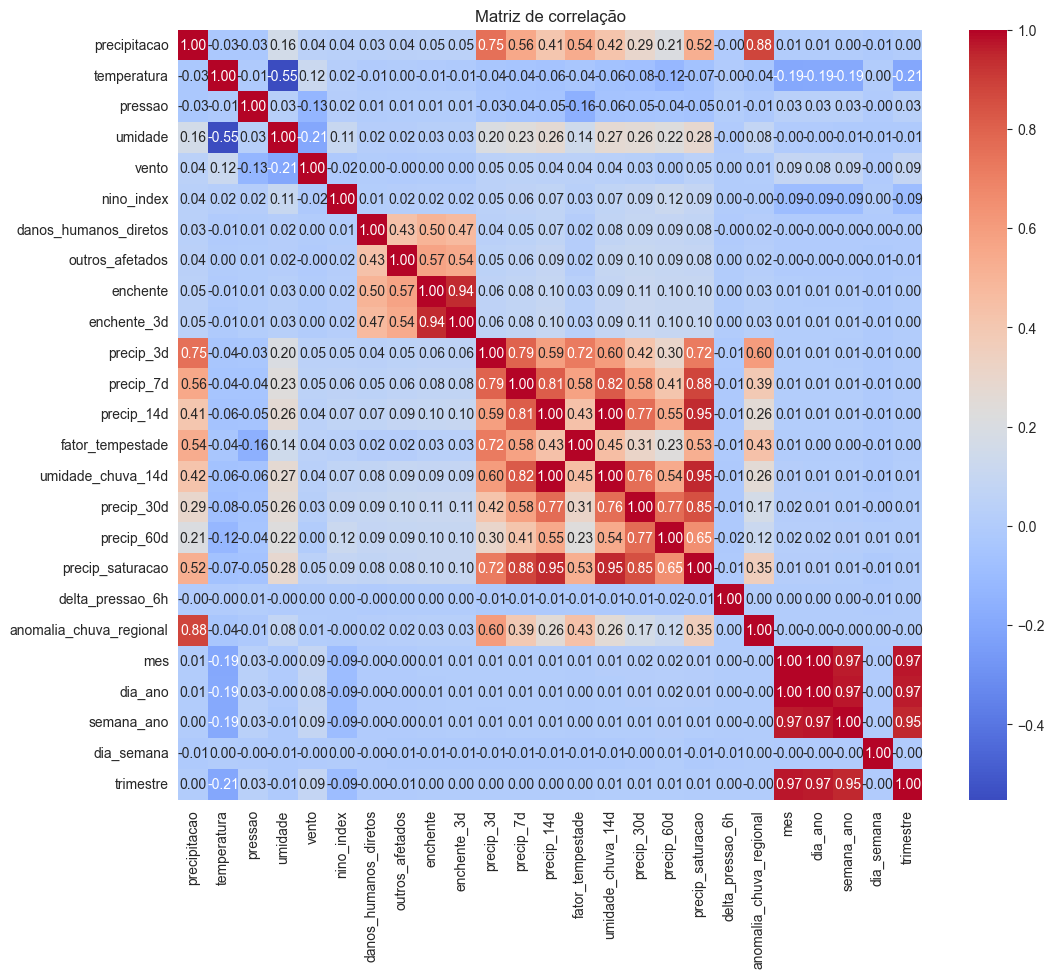

,precipitacao,temperatura,pressao,umidade,vento,nino_index,danos_humanos_diretos,outros_afetados,enchente,enchente_3d,...,precip_30d,precip_60d,precip_saturacao,delta_pressao_6h,anomalia_chuva_regional,mes,dia_ano,semana_ano,dia_semana,trimestre
precipitacao,1.000000,-0.030220,-0.026463,0.159335,0.042956,3.562651e-02,0.030966,0.037913,0.045968,0.045508,...,0.293443,0.211222,0.521399,-0.004938,8.822572e-01,5.780553e-03,5.424822e-03,4.612744e-03,-7.321331e-03,2.360358e-03
temperatura,-0.030220,1.000000,-0.007498,-0.551550,0.120444,1.931132e-02,-0.005816,0.000192,-0.006010,-0.006546,...,-0.077371,-0.121249,-0.065171,-0.001474,-3.791661e-02,-1.947004e-01,-1.928822e-01,-1.916160e-01,1.001404e-03,-2.056296e-01
pressao,-0.026463,-0.007498,1.000000,0.027280,-0.129437,1.715829e-02,0.005772,0.007107,0.010007,0.011018,...,-0.051898,-0.044419,-0.054658,0.006497,-1.251724e-02,3.109571e-02,3.066965e-02,3.049969e-02,-3.106043e-04,3.285743e-02
umidade,0.159335,-0.551550,0.027280,1.000000,-0.205881,1.075382e-01,0.017922,0.017241,0.025992,0.026747,...,0.259081,0.224934,0.282412,-0.004555,8.106887e-02,-1.845135e-03,-3.234330e-03,-9.973433e-03,-1.178508e-02,-9.938277e-03
vento,0.042956,0.120444,-0.129437,-0.205881,1.000000,-1.520348e-02,0.000530,-0.000912,0.004296,0.002846,...,0.028461,0.001393,0.046149,0.002362,8.937549e-03,8.559133e-02,8.462244e-02,8.642307e-02,-4.990306e-03,8.854791e-02
nino_index,0.035627,0.019311,0.017158,0.107538,-0.015203,1.000000e+00,0.011146,0.017540,0.020853,0.020602,...,0.090284,0.116947,0.088618,0.004681,-2.307908e-17,-9.191914e-02,-9.186713e-02,-9.424425e-02,8.694433e-04,-9.473756e-02
danos_humanos_diretos,0.030966,-0.005816,0.005772,0.017922,0.000530,1.114586e-02,1.000000,0.430914,0.497158,0.469056,...,0.091379,0.089815,0.076802,-0.000300,1.727117e-02,-3.087133e-03,-4.163087e-03,-4.060868e-03,-8.724687e-04,-4.486738e-03
outros_afetados,0.037913,0.000192,0.007107,0.017241,-0.000912,1.753951e-02,0.430914,1.000000,0.574619,0.542138,...,0.103176,0.094003,0.084897,0.000658,2.334612e-02,-3.593267e-03,-3.768619e-03,-3.503093e-03,-6.144536e-03,-5.903218e-03
enchente,0.045968,-0.006010,0.010007,0.025992,0.004296,2.085296e-02,0.497158,0.574619,1.000000,0.943475,...,0.111582,0.102198,0.102208,0.000702,2.668450e-02,6.098094e-03,5.816245e-03,5.909241e-03,-8.932448e-03,2.536583e-03
enchente_3d,0.045508,-0.006546,0.011018,0.026747,0.002846,2.060232e-02,0.469056,0.542138,0.943475,1.000000,...,0.111105,0.101043,0.102658,0.000231,2.714840e-02,7.111055e-03,6.953820e-03,6.993798e-03,-7.923668e-03,3.191430e-03


In [62]:
feature_cols = [
    "precipitacao",
    "temperatura",
    "pressao",
    "umidade",
    "vento",
    # "nivel_rio",
    "nino_index",
    "danos_humanos_diretos",
]

numeric_features = feature_cols + [
    "precip_3d",
    "precip_7d",
    "precip_14d",
    "fator_tempestade",
    "umidade_chuva_14d",
    "precip_30d",
    "precip_60d",
    "precip_saturacao",
    "delta_pressao_6h",
   # "delta_rio_1d",
    #"delta_rio_3d",
]
categorical_features = ["mes", "dia_ano", "semana_ano", "dia_semana", "trimestre"]
all_features_model = numeric_features + categorical_features

train_df = df[df["data_hora"] <= TRAIN_END].copy()
valid_df = df[(df["data_hora"] > TRAIN_END) & (df["data_hora"] <= VALID_END)].copy()
test_df = df[df["data_hora"] > VALID_END].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test:", test_df.shape)

def build_tabular_dataset(df, feature_columns, target_column):
    X = df[feature_columns].copy()
    y = df[target_column].copy()
    return X, y

# Exemplo de uso com dados tabulares:
X_train, y_train = build_tabular_dataset(train_df, all_features_model, TARGET)
X_valid, y_valid = build_tabular_dataset(valid_df, all_features_model, TARGET)
X_test, y_test = build_tabular_dataset(test_df, all_features_model, TARGET)

print("Colunas presentes em X_train:", list(X_train.columns))

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlação")
plt.show()

corr

## 7. Criação das sêquencias temporais

In [63]:
def create_sequences_by_station(df, feature_cols, target_col, lookback, forecast):
    """
    Garante a criação de sequências 3D respeitando o agrupamento por estação meteorológica,
    sem misturar o final do histórico de uma cidade com o começo de outra.
    """
    X, y = [], []
    
    for station_id, group in df.groupby("estacao_id"):
        # Transforma os dados da estação em matriz
        feat_matrix = group[feature_cols].values
        target_vector = group[target_col].values
        
        if len(feat_matrix) < (lookback + forecast):
            continue
            
        for i in range(len(feat_matrix) - lookback - forecast + 1):
            X.append(feat_matrix[i : i + lookback])
            # Alvo é o indicador correspondente ao horizonte final planejado
            y.append(target_vector[i + lookback + forecast - 1])
            
    return np.array(X), np.array(y)

# 1. Aplicando Normalização correta com fit APENAS no treino para evitar leakage
scaler_lstm = MinMaxScaler()

# Filtrando as colunas numéricas de interesse do LSTM
lstm_features = [col for col in all_features_model if col in FEATURES]

# Clonando os dataframes de partição temporal para não corromper a base original
train_seq_df = train_df.copy().sort_values(["estacao_id", "data_hora"])
valid_seq_df = valid_df.copy().sort_values(["estacao_id", "data_hora"])

# Fit no Treino, Transform no Treino e na Validação
train_seq_df[lstm_features] = scaler_lstm.fit_transform(train_seq_df[lstm_features].fillna(0))
valid_seq_df[lstm_features] = scaler_lstm.transform(valid_seq_df[lstm_features].fillna(0))

# 2. Gerando as matrizes sequenciais de forma totalmente isolada
X_train_seq, y_train_seq = create_sequences_by_station(train_seq_df, lstm_features, TARGET, LOOKBACK, FORECAST)
X_valid_seq, y_valid_seq = create_sequences_by_station(valid_seq_df, lstm_features, TARGET, LOOKBACK, FORECAST)

print("Estrutura das matrizes para o LSTM:")
print(f"X Treino: {X_train_seq.shape} | y Treino: {y_train_seq.shape}")
print(f"X Validação: {X_valid_seq.shape} | y Validação: {y_valid_seq.shape}")

Estrutura das matrizes para o LSTM:
X Treino: (236946, 14, 7) | y Treino: (236946,)
X Validação: (87440, 14, 7) | y Validação: (87440,)


## 8. Baseline model

In [64]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Calcular a proporção real de desequilíbrio para passar ao XGBoost
classes_counts = y_train.value_counts()
sub_proporcao = classes_counts[0] / max(classes_counts[1], 1)

print(f"Proporção de desequilíbrio de classe (Negativos / Positivos): {sub_proporcao:.2f}")

# Reconfigurando preprocessor e os modelos com estratégias de peso
from sklearn.utils.class_weight import compute_class_weight

# Calculando pesos para o Random Forest
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
rf_weight_dict = {0: class_weights[0], 1: class_weights[1]}

models = {
    "Logistic Regression (Balanced)": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=RANDOM_STATE),
    "XGBoost (Weighted)": xgb.XGBClassifier(scale_pos_weight=sub_proporcao, max_delta_step=1, random_state=RANDOM_STATE, eval_metric='logloss'),
    "LightGBM (Isotonic/Balanced)": lgb.LGBMClassifier(
        class_weight='balanced',
        min_child_samples=5,      # Permite folhas menores para capturar os 130 casos
        learning_rate=0.03,
        n_estimators=200,
        random_state=RANDOM_STATE,
        verbose=-1
    )
}

tabular_results = []

for name, model_obj in models.items():
    clf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model_obj)
    ])
    
    # Treino
    clf_pipeline.fit(X_train, y_train)

    # Exemplo para a Regressão Logística ou XGBoost
    # Pegar a probabilidade da classe 1 (Com Enchente)
    y_probs = clf_pipeline.predict_proba(X_valid)[:, 1]

    # Testar diferentes limiares de corte
    preds = (y_probs >= 0.05).astype(int)
    print(f"--- Threshold: 0.05 ---")
    print(f"Recall: {recall_score(y_valid, preds):.2f} | Falsos Positivos: {confusion_matrix(y_valid, preds)[0,1]}")

    #preds = clf_pipeline.predict(X_valid)
    
    print(f"\n================ Relatório: {name} ================")
    print(classification_report(y_valid, preds, target_names=["Sem Enchente", "Com Enchente"], zero_division=0))
    print("Matriz de Confusão:")
    print(confusion_matrix(y_valid, preds))
    
    # Armazenando métricas focadas na classe 1 (Enchente)
    tabular_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Recall (Enchente)": recall_score(y_valid, preds, pos_label=1, zero_division=0),
        "F1-Score (Enchente)": f1_score(y_valid, preds, pos_label=1, zero_division=0)
    })

df_tabular_perf = pd.DataFrame(tabular_results)
display(df_tabular_perf)

Proporção de desequilíbrio de classe (Negativos / Positivos): 1323.61
--- Threshold: 0.05 ---
Recall: 0.55 | Falsos Positivos: 0

================ Relatório: Logistic Regression (Balanced) ================
              precision    recall  f1-score   support

Sem Enchente       1.00      1.00      1.00     87470
Com Enchente       1.00      0.55      0.71       130

    accuracy                           1.00     87600
   macro avg       1.00      0.78      0.86     87600
weighted avg       1.00      1.00      1.00     87600

Matriz de Confusão:
[[87470     0]
 [   58    72]]
--- Threshold: 0.05 ---
Recall: 0.55 | Falsos Positivos: 181

================ Relatório: Random Forest (Balanced) ================
              precision    recall  f1-score   support

Sem Enchente       1.00      1.00      1.00     87470
Com Enchente       0.28      0.55      0.38       130

    accuracy                           1.00     87600
   macro avg       0.64      0.78      0.69     87600
weighted avg

,Model,Accuracy,Recall (Enchente),F1-Score (Enchente)
0,Logistic Regression (Balanced),0.999338,0.553846,0.712871
1,Random Forest (Balanced),0.997272,0.553846,0.375979
2,XGBoost (Weighted),0.998973,0.330769,0.488636
3,LightGBM (Isotonic/Balanced),0.998345,0.000000,0.000000


## 9. Improved model

In [ ]:
from keras.layers import Input

# Calculando pesos para balanceamento no gradiente do LSTM
neg, pos = np.bincount(y_train_seq.astype(int))
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
lstm_class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"Pesos atribuídos no LSTM -> Classe 0: {weight_for_0:.2f}, Classe 1: {weight_for_1:.2f}")

# Definindo arquitetura estável
model_lstm = Sequential([
    Input(shape=(LOOKBACK, len(lstm_features))),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Ativação Sigmoid para probabilidade binária
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Recall']
)

# Treinamento aplicando os pesos corrigidos
history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_valid_seq, y_valid_seq),
    epochs=15,
    batch_size=256,
    class_weight=lstm_class_weights,
    verbose=1
)

Epoch 1/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 243s 17ms/step - accuracy: 0.3340 - loss: 0.0114 - val_accuracy: 0.9424 - val_loss: 6.5557e-04
Epoch 2/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 261s 18ms/step - accuracy: 0.3014 - loss: 0.0080 - val_accuracy: 0.0000e+00 - val_loss: 5.7329e-04
Epoch 3/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 281s 20ms/step - accuracy: 0.2591 - loss: 0.0073 - val_accuracy: 0.1339 - val_loss: 0.0015
Epoch 4/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 251s 18ms/step - accuracy: 0.2091 - loss: 0.0068 - val_accuracy: 1.2437e-05 - val_loss: 3.8327e-04
Epoch 5/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 216s 15ms/step - accuracy: 0.2001 - loss: 0.0063 - val_accuracy: 0.0000e+00 - val_loss: 6.8783e-04
Epoch 6/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 191s 13ms/step - accuracy: 0.1603 - loss: 0.0059 - val_accuracy: 0.3751 - val_loss: 8.2505e-04
Epoch 7/20
14239/14239 ━━━━━━━━━━━━━━━━━━━━ 223s 16ms/step - accuracy: 0.1894 - loss: 0.0058 - val_accuracy: 1.2437e-05 - val_loss: 6.1064e-04
Epoch 8/20
1423

## 10. Compare models

In [ ]:
# Predições probabilísticas do LSTM
raw_preds_lstm = model_lstm.predict(X_valid_seq)
# Convertendo para binário (limiar padrão 0.50)
binary_preds_lstm = (raw_preds_lstm > 0.5).astype(int).flatten()

print("\n================ Relatório Final: LSTM Corrigido ================")
print(classification_report(y_valid_seq, binary_preds_lstm, target_names=["Sem Enchente", "Com Enchente"], zero_division=0))

print("Matriz de Confusão LSTM:")
print(confusion_matrix(y_valid_seq, binary_preds_lstm))

Distribuição de classes (enchente):
enchente
0    0.998926
1    0.001074
Name: proportion, dtype: float64
2513/2513 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step
=== Day +1 Forecast ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     80408
       Flood       0.00      0.00      0.00         0

    accuracy                           1.00     80408
   macro avg       0.50      0.50      0.50     80408
weighted avg       1.00      1.00      1.00     80408

[[80408]]
=== Day +2 Forecast ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     80408
       Flood       0.00      0.00      0.00         0

    accuracy                           1.00     80408
   macro avg       0.50      0.50      0.50     80408
weighted avg       1.00      1.00      1.00     80408

[[80408]]
=== Day +3 Forecast ===
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00     8

,model,accuracy,recall,f1_score
0,Baseline,0.998516,0.500000,0.499629
1,Random Forest,0.998505,0.499994,0.499626
2,XGBoost,0.998505,0.499994,0.499626
3,LightGBM,0.998071,0.499777,0.499517
4,Improved LSTM,1.000000,1.000000,1.000000


## 11. Interpretabilidade
primeira coisa a ser descartada caso falte tempo


In [2]:
# Interpretação de modelos de árvore usando SHAP
preprocessed_valid = preprocessor.transform(X_valid)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgboost_model.named_steps['model'])
shap_values = explainer.shap_values(preprocessed_valid)

shap.summary_plot(
    shap_values,
    preprocessed_valid,
    feature_names=feature_names,
    show=False,
)
plt.tight_layout()
plt.show()

NameError: name 'preprocessor' is not defined

## 12. Gerar predição atual


In [21]:
# Exemplo de uso para gerar predição com o último bloco de dados disponíveis.
# Substitua '123' pelo estacao_id que deseja prever, ou use a última estação do conjunto.
station_id = df["estacao_id"].iloc[-1]
recent_14_days = (
    df[df["estacao_id"] == station_id]
    .sort_values("data_hora")
    .tail(LOOKBACK)[feature_cols]
    .values
)

if recent_14_days.shape[0] != LOOKBACK:
    raise ValueError(f"Não há dados suficientes para criar a sequência de {LOOKBACK} dias para a estação {station_id}.")

input_tensor = recent_14_days.reshape(1, LOOKBACK, len(feature_cols))
forecast = improved_model.predict(input_tensor)[0]

for i, prob in enumerate(forecast, start=1):
    print(f"Day +{i} flood probability: {prob:.2%}")

# O forecast representa a probabilidade de enchente para os próximos 3 dias.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Day +1 flood probability: 18.17%
Day +2 flood probability: 18.71%
Day +3 flood probability: 15.28%


## Research Hypotheses

H1:
Acúmulo de chuva em 7 dias possui maior poder preditivo
do que chuva diária.

H2:
Nível do rio é a variável mais importante.

H3:
Eventos El Niño aumentam a frequência de enchentes.

H4:
Modelos baseados em árvores superam regressão logística.

H5:
LSTM supera modelos tabulares quando há dados suficientes.